# Bootstrap our data!

## Setup and model definition
This notebook evaluates the **4-component** `lymixture` fit using bootstrap/resampling results.

What happens here, at a high level:
- Load the preprocessed dataset (`data/filtered_4.csv`) and derive an `early`/`late` T-stage label.
- Define the lymphatic spread graph and instantiate a `LymphMixture(num_components=4)` model.
- Load the *original* fitted parameters and then read bootstrapped optimal parameters from disk (`histories/4/resampling/optimal_params`).
- Use the bootstrap parameter sets to compute uncertainty/credible intervals for model parameters and mixture coefficients.
- Compute prevalence and risk distributions per subsite and stage, used for paper figures.

Notes:
- Many plotting cells are intentionally hard-coded to reproduce specific paper panels.
- The heavy computation (bootstrap fitting) is assumed to be done already; this notebook is mainly **post-hoc evaluation + plotting**.

In [11]:
import numpy as np
import pandas as pd
from lymph.models import Unilateral
from lymixture import LymphMixture
from lymixture.utils import binom_pmf, late_binomial

usz_blue = '#005ea8'
usz_green = '#00afa5'
usz_red = '#ae0060'
usz_orange = '#f17900'
usz_gray = '#c5d5db'

dataset = pd.read_csv('data/filtered_4_precomputed.csv', header = [0,1,2],)
dataset_staging = dataset.copy()
dataset_staging['tumor','1','t_stage'] = dataset_staging['tumor','1','t_stage'].replace([0,1,2], 'early')
dataset_staging['tumor','1','t_stage'] = dataset_staging['tumor','1','t_stage'].replace([3,4], 'late')

/tmp/ipykernel_44238/346982256.py:13: DtypeWarning: Columns (0,30,44,59,73,88,102,117,131,146,160,166,167,168,174,180,181,190,196,197,203,204,210,226,242,243,244,245,246,247,248,249,250,251,252,253,254,255,256,257,258,274,287,288,289,290,291,292,293,294,295,296,297,298,299,300,301,302,303,304,305,306,307,308,309,310,311,312,313,314,315,316,317,318,358,371,372,373,374,375,376,377,378,379,380,381,382,383,384,393,394,395,397,398,400,405,409,410,411,413,414) have mixed types. Specify dtype option on import or set low_memory=False.
  dataset = pd.read_csv('data/filtered_4_precomputed.csv', header = [0,1,2],)


In [12]:
dataset_staging['tumor','1','subsite'].value_counts()

(tumor, 1, subsite)
C09      452
C32.0    431
C32.1    357
C12      227
C01      212
C10      169
C13      165
C02      158
C04       99
C05       61
C06       46
C03       45
C32.2     15
Name: count, dtype: int64

In [13]:
graph = {
    ("tumor", "primary"): ["I", "II", "III", "IV", "V"],
    ("lnl", "I"): ["II"],
    ("lnl", "II"): ["III"],
    ("lnl", "III"): ["IV"],
    ("lnl", "IV"): ["V"],
    ("lnl", "V"): [],
}

num_components = 4

mixture = LymphMixture(
    model_cls=Unilateral,
    model_kwargs={"graph_dict": graph},
    num_components=num_components,
    universal_p= False
)

mixture.load_patient_data(
    dataset_staging,
    split_by=("tumor", "1", "subsite"),
    mapping=lambda x: x,
)

mixture.set_distribution("early", binom_pmf(np.arange(11), 10, 0.3))
mixture.set_distribution("late", late_binomial)
mixture.set_modality("max_llh", 1., 1.)

In [14]:
initial_params = pd.read_csv('histories_precomputed/4/original_fit/optimal_params.csv', index_col=0)["value"].to_dict()
mixture.set_params(**initial_params)
mixture.get_mixture_coefs()

,C01,C02,C03,C04,C05,C06,C09,C10,C12,C13,C32.0,C32.1,C32.2
0,0.000000,0.159996,0.000343,0.130781,0.008910,0.289573,0.074037,0.187829,0.102110,0.177894,9.858742e-01,0.476127,1.0
1,0.762912,0.286089,0.054896,0.158468,0.446058,0.137824,0.707603,0.470344,0.019534,0.069030,0.000000e+00,0.120196,0.0
2,0.216629,0.094418,0.000000,0.043585,0.023400,0.000000,0.177555,0.271765,0.878356,0.753076,1.412567e-02,0.403676,0.0
3,0.020459,0.459497,0.944761,0.667166,0.521633,0.572603,0.040806,0.070062,0.000000,0.000000,1.277115e-07,0.000000,0.0


In [15]:
best_params = []
for index in range(200):
    file_prefix = f"dataset_{index}"
    best_params.append(pd.read_csv(f"histories_precomputed/4/resampling/optimal_params/{file_prefix}_optimal_params.csv", index_col=0)["value"].to_dict())

### Bootstrap uncertainty for component parameters
We read the best-fit parameters from each bootstrap replicate (`best_params`) and summarize uncertainty per mixture component.

Implementation detail: for each parameter we take the fitted optimum from the original 4-component fit (`optima_*`) as the point estimate, and compute a **68% interval** around it by selecting the closest 68% of bootstrap samples (by absolute distance).
This produces asymmetric error bars while staying robust to skewed / multi-modal bootstrap distributions.

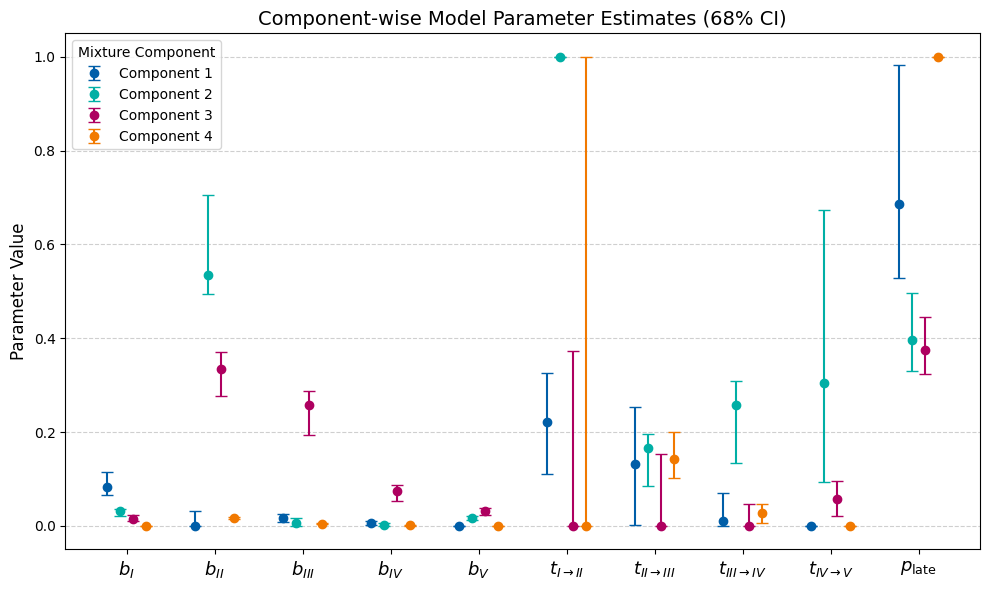

In [16]:
import numpy as np
import matplotlib.pyplot as plt

keys_0 = ['0_primarytoI_spread', '0_primarytoII_spread', '0_primarytoIII_spread', '0_primarytoIV_spread', '0_primarytoV_spread', 
    '0_ItoII_spread', '0_IItoIII_spread', '0_IIItoIV_spread', '0_IVtoV_spread', '0_late_p']
keys_1 = ['1_primarytoI_spread', '1_primarytoII_spread', '1_primarytoIII_spread', '1_primarytoIV_spread', '1_primarytoV_spread', 
    '1_ItoII_spread', '1_IItoIII_spread', '1_IIItoIV_spread', '1_IVtoV_spread', '1_late_p']
keys_2 = ['2_primarytoI_spread', '2_primarytoII_spread', '2_primarytoIII_spread', '2_primarytoIV_spread', '2_primarytoV_spread', 
    '2_ItoII_spread', '2_IItoIII_spread', '2_IIItoIV_spread', '2_IVtoV_spread', '2_late_p']
keys_3 = ['3_primarytoI_spread', '3_primarytoII_spread', '3_primarytoIII_spread', '3_primarytoIV_spread', '3_primarytoV_spread',
    '3_ItoII_spread', '3_IItoIII_spread', '3_IIItoIV_spread', '3_IVtoV_spread', '3_late_p']

# Custom parameter labels
labels = [r'$b_I$', r'$b_{II}$', r'$b_{III}$', r'$b_{IV}$', r'$b_{V}$',
          r'$t_{I \to II}$', r'$t_{II \to III}$', r'$t_{III \to IV}$', r'$t_{IV \to V}$', r'$p_{\mathrm{late}}$']

# Colors for components
usz_colors = [usz_blue, usz_green, usz_red, usz_orange]

# Compute stats for each component
def get_stats(keys, best_params_list, optima = None, equal_tailed = True, percentile_range=0.68):
    means = []
    lower_errors = []
    upper_errors = []
    for index, key in enumerate(keys):
        values = np.array([bp[key] for bp in best_params_list])
        values = sorted(values)
        n_values = len(values)
        n_within_range = int(np.ceil(percentile_range * n_values))
        if optima is not None:
            mean = optima[index]
        else:
            mean = np.mean(values)
        if equal_tailed:
            # Equal-tailed percentile interval:
            # 68% -> 16th and 84th percentiles
            tail_probability = (1.0 - percentile_range) / 2.0
            lower_bound, upper_bound = np.quantile(
                values,
                [tail_probability, 1.0 - tail_probability],
            )
            low_err = max(mean - lower_bound, 0)
            high_err = max(upper_bound - mean, 0)
        else:
            # Legacy interval: retain the sampled values closest
            # to the point estimate.
            distances = [abs(v - mean) for v in values]
            sorted_indices = np.argsort(distances)
            closest_indices = sorted_indices[:n_within_range]
            # Extract the 68% range
            percentile_values = [values[i] for i in closest_indices]
            percentile_values.sort()
            low_err = max(mean - min(percentile_values), 0)
            high_err = max(max(percentile_values) - mean, 0)
        means.append(mean)
        lower_errors.append(low_err)
        upper_errors.append(high_err)
    return means, [lower_errors, upper_errors]

# Get optima
optima_0 = [mixture.get_params()[key] for key in keys_0]
optima_1 = [mixture.get_params()[key] for key in keys_1]
optima_2 = [mixture.get_params()[key] for key in keys_2]
optima_3 = [mixture.get_params()[key] for key in keys_3]

# Compute statistics
means_all = []
yerrs_all = []
keys_all = [keys_3, keys_1, keys_2, keys_0]
optima_all = [optima_3, optima_1, optima_2, optima_0]
for k, o in zip(keys_all, optima_all):
    means, yerr = get_stats(k, best_params, o)
    means_all.append(means)
    yerrs_all.append(yerr)

# Plot
plt.figure(figsize=(10, 6))
x = np.arange(len(keys_0))
for i, (means, yerr) in enumerate(zip(means_all, yerrs_all)):
    plt.errorbar(x + (i - 1.5) * 0.15, means, yerr=yerr,
                 fmt='o', color=usz_colors[i], ecolor=usz_colors[i],
                 capsize=4, markersize=6, label=f'Component {i+1}')

plt.xticks(x, labels, fontsize=13)
plt.ylabel('Parameter Value', fontsize=12)
plt.title('Component-wise Model Parameter Estimates (68% CI)', fontsize=14)
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.legend(fontsize=10, title='Mixture Component')
plt.tight_layout()
# plt.savefig('all_params_optima_credibility_interval.pdf')
plt.show()


Note: Here $t_{I \rightarrow II}$ is fully identifiable. However, we show in the next plot that similarly to the figure in the paper it is completely undefined. In this case there are just more samples with 0 value such that the CI looks very tight around 0.

(array([139.,   0.,   0.,   1.,   0.,   0.,   0.,   0.,   0.,  60.]),
 array([6.61069614e-05, 1.00056134e-01, 2.00046161e-01, 3.00036188e-01,
        4.00026215e-01, 5.00016242e-01, 6.00006269e-01, 6.99996296e-01,
        7.99986323e-01, 8.99976350e-01, 9.99966377e-01]),
 <BarContainer object of 10 artists>)

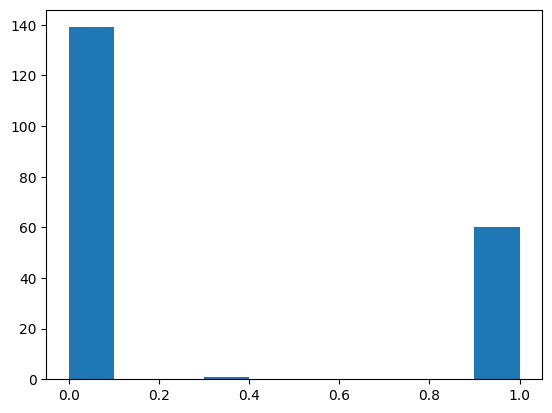

In [17]:
mixture.get_params()
values = []
for bp in best_params:
    values.append(bp['0_ItoII_spread'])
plt.hist(values)

### Mixture coefficients (subsite → component weights)
`mixture.get_mixture_coefs()` returns the fitted mixture weights per subsite (columns are subsites, rows are components).

The heatmap below visualizes these coefficients for the **original (non-bootstrap) optimum** to interpret the components (e.g., “oropharynx-like”, “larynx-like”).
The following scatter/errorbar plot repeats this for the bootstrap results, providing a 68% uncertainty interval per coefficient.

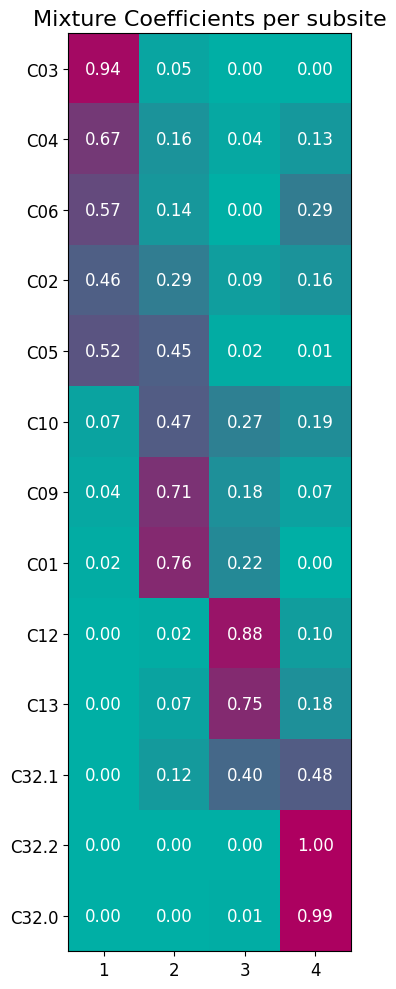

In [18]:
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

# USZ colors
usz_blue = '#005ea8'
usz_green = '#00afa5'
usz_red = '#ae0060'
usz_orange = '#f17900'
usz_gray = '#c5d5db'

# colormaps
white_to_blue  = LinearSegmentedColormap.from_list("white_to_blue", 
                                                   ["#ffffff", usz_blue], 
                                                   N=256)
white_to_green = LinearSegmentedColormap.from_list("white_to_green", 
                                                   ["#ffffff", usz_green], 
                                                   N=256)
green_to_red   = LinearSegmentedColormap.from_list("green_to_red", 
                                                   [usz_green, usz_red], 
                                                   N=256)

h = usz_gray.lstrip('#')
gray_rgba = tuple(int(h[i:i+2], 16) / 255. for i in (0, 2, 4)) + (1.0,)
tmp = LinearSegmentedColormap.from_list("tmp", [usz_green, usz_red], N=128)

matrix = mixture.get_mixture_coefs()[['C03', 'C04', 'C06', 'C02', 'C05', 'C10', 'C09','C01', 'C12', 'C13','C32.1','C32.2', 'C32.0']]
new_order = [3, 1, 2, 0]  
matrix = matrix.reindex(new_order)
# Transpose the matrix to rotate by 90°
matrix_rotated = matrix.T
# Create the figure and axis
fig, ax = plt.subplots(figsize=(8, 10))

# Display the rotated matrix using imshow
cax = ax.imshow(matrix_rotated.values, cmap=tmp, origin='upper')

# Loop over the data and create text annotations
for i in range(matrix_rotated.shape[0]):  # Rows (previously columns)
    for j in range(matrix_rotated.shape[1]):  # Columns (previously rows)
        value = matrix_rotated.iloc[i, j]
        ax.text(j, i, f"{value:.2f}", ha="center", va="center", 
                color="white", fontsize=12)


# Optional: Set axis labels and title
ax.set_xticks(range(matrix_rotated.shape[1]))
ax.set_xticklabels([1, 2, 3, 4], fontsize=12)  # Custom labels
ax.set_yticks(range(matrix_rotated.shape[0]))
ax.set_yticklabels(matrix.columns, fontsize = 12)  # Original column labels
ax.set_title("Mixture Coefficients per subsite", fontsize = 16)
fig.tight_layout()
# fig.savefig('mixture_components_4.pdf', bbox_inches='tight')
plt.show()
# Set x-axis labels to 0, 1, 2, 3


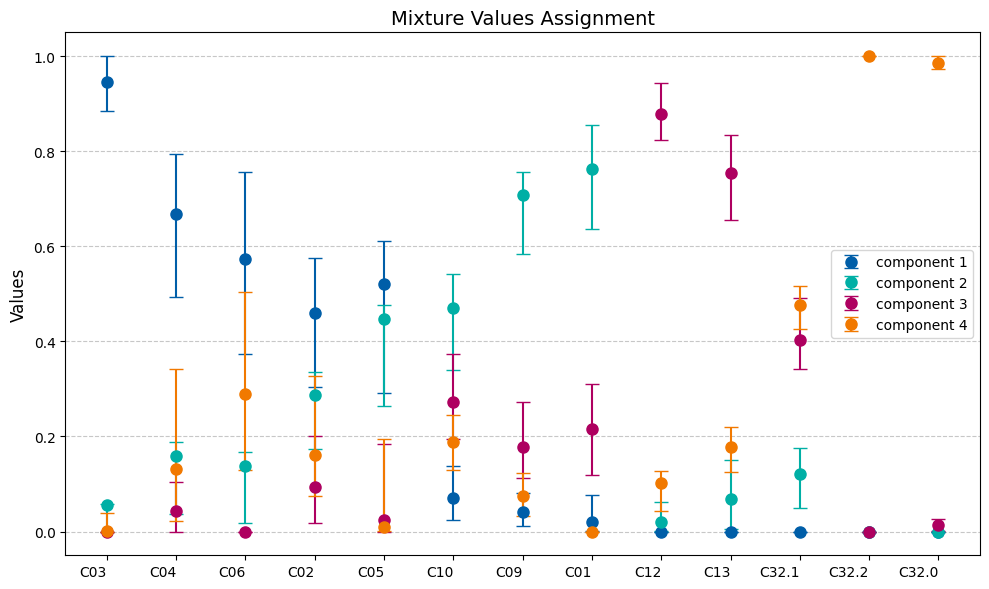

In [19]:
all_keys = mixture.get_params().keys()
mixture_keys= [key for key in all_keys if 'coef' in key]
keys_0 = [key for key in mixture_keys if '0_C' in key]
keys_1 = [key for key in mixture_keys if '1_C' in key]
keys_2 = [key for key in mixture_keys if '2_C' in key]
keys_3 = [key for key in mixture_keys if '3_C' in key]

order_idx = [2, 3, 5, 1, 4, 7, 6, 0, 8, 9, 11, 12, 10]
matrix = mixture.get_mixture_coefs()
matrix = matrix.loc[:, [matrix.columns[i] for i in order_idx]]

# Get the optimal parameters as means
optima_0 = mixture.get_mixture_coefs().loc[0].to_list()
optima_1 = mixture.get_mixture_coefs().loc[1].to_list()
optima_2 = mixture.get_mixture_coefs().loc[2].to_list()
optima_3 = mixture.get_mixture_coefs().loc[3].to_list()

# Compute stats for each component
means_0, yerr_0 = get_stats(keys_0, best_params, optima_0)
means_1, yerr_1 = get_stats(keys_1, best_params, optima_1)
means_2, yerr_2 = get_stats(keys_2, best_params, optima_2)
means_3, yerr_3 = get_stats(keys_3, best_params, optima_3)

means_0_sorted = np.array(means_0)[[2,3,5,1,4,7,6,0,8,9,11,12,10]]
y_err_0_sorted = np.array(yerr_0)[:, [2,3,5,1,4,7,6,0,8,9,11,12,10]]
means_1_sorted = np.array(means_1)[[2,3,5,1,4,7,6,0,8,9,11,12,10]]
y_err_1_sorted = np.array(yerr_1)[:, [2,3,5,1,4,7,6,0,8,9,11,12,10]]
means_2_sorted = np.array(means_2)[[2,3,5,1,4,7,6,0,8,9,11,12,10]]
y_err_2_sorted = np.array(yerr_2)[:, [2,3,5,1,4,7,6,0,8,9,11,12,10]]
means_3_sorted = np.array(means_3)[[2,3,5,1,4,7,6,0,8,9,11,12,10]]
y_err_3_sorted = np.array(yerr_3)[:, [2,3,5,1,4,7,6,0,8,9,11,12,10]]

# Plot
plt.figure(figsize=(10, 6))
x = np.arange(len(keys_0))
plt.errorbar(x, means_3_sorted, yerr=y_err_3_sorted, fmt='o', color=usz_blue, ecolor=usz_blue, capsize=5, markersize=8, label='component 1')
plt.errorbar(x, means_1_sorted, yerr=y_err_1_sorted, fmt='o', color=usz_green, ecolor=usz_green, capsize=5, markersize=8, label='component 2')
plt.errorbar(x, means_2_sorted, yerr=y_err_2_sorted, fmt='o', color=usz_red, ecolor=usz_red, capsize=5, markersize=8, label='component 3')
plt.errorbar(x, means_0_sorted, yerr=y_err_0_sorted, fmt='o', color=usz_orange, ecolor=usz_orange, capsize=5, markersize=8, label='component 4')

plt.xticks(x, ['C03', 'C04', 'C06', 'C02', 'C05', 'C10', 'C09','C01', 'C12', 'C13','C32.1','C32.2', 'C32.0'], rotation=0, ha='right', fontsize=10)
plt.legend(fontsize=10)
plt.ylabel('Values', fontsize=12)
plt.title('Mixture Values Assignment', fontsize=14)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
# plt.savefig('4_comp_mixture_coefficients_uncert_scatter.pdf')
plt.show()


# Prevalence plots (unconditional)
In this section we compute **unconditional prevalence/risk distributions** per subsite and T-stage by evaluating `mixture.risk(...)` on each bootstrap parameter set.

- For each bootstrap replicate, we set the model parameters and compute the probability of involvement for single LNLs (I–V).
- We also compute a few combined events like `II & III` and `not II & III` that are used later for paper figures.

The plotting helper `multiple_plotter_by_lnl(...)` overlays:
- a histogram of model-predicted risks across bootstrap replicates, and
- a Beta posterior for the observed prevalence in the dataset (counts shown in the legend).

In [ ]:
subsite_dictionary_early_prevalence = {}
subsite_dictionary_late_prevalence = {}
subsite_list = list(mixture.subgroups.keys())
for subsite in subsite_list:
    subsite_dictionary_early_prevalence[subsite] = {
        'I': [],
        'II': [],
        'III': [],
        'IV': [],
        'V': [],
        'II_III' : [],
        'not_II_III' : []
    }
    subsite_dictionary_late_prevalence[subsite] = {
        'I': [],
        'II': [],
        'III': [],
        'IV': [],
        'V': [],
        'II_III' : [],
        'not_II_III' : []    
    }
    
involvement_I = {'I': True}
involvement_II = {'II': True}
involvement_III = {'III': True}
involvement_IV = {'IV': True}
involvement_V = {'V': True}
involvement_II_III = {'II': True, 'III': True}
involvement_not_II_III = {'II': False, 'III': True}
# Loop through samples first
for params in best_params:
    mixture.set_params(**params)
    for subsite in subsite_list:
        risk_dictionary_early = subsite_dictionary_early_prevalence[subsite]
        risk_dictionary_late = subsite_dictionary_late_prevalence[subsite]
        
        # Append risk values to the respective keys
        risk_dictionary_early['I'].append(mixture.risk(subgroup=subsite, involvement=involvement_I, t_stage='early'))
        risk_dictionary_early['II'].append(mixture.risk(subgroup=subsite, involvement=involvement_II, t_stage='early'))
        risk_dictionary_early['III'].append(mixture.risk(subgroup=subsite, involvement=involvement_III, t_stage='early'))
        risk_dictionary_early['IV'].append(mixture.risk(subgroup=subsite, involvement=involvement_IV, t_stage='early'))
        risk_dictionary_early['V'].append(mixture.risk(subgroup=subsite, involvement=involvement_V, t_stage='early'))
        risk_dictionary_early['II_III'].append(mixture.risk(subgroup=subsite, involvement=involvement_II_III, t_stage='early'))
        risk_dictionary_early['not_II_III'].append(mixture.risk(subgroup=subsite, involvement=involvement_not_II_III, t_stage='early'))
        
        risk_dictionary_late['I'].append(mixture.risk(subgroup=subsite, involvement=involvement_I, t_stage='late'))
        risk_dictionary_late['II'].append(mixture.risk(subgroup=subsite, involvement=involvement_II, t_stage='late'))
        risk_dictionary_late['III'].append(mixture.risk(subgroup=subsite, involvement=involvement_III, t_stage='late'))
        risk_dictionary_late['IV'].append(mixture.risk(subgroup=subsite, involvement=involvement_IV, t_stage='late'))
        risk_dictionary_late['V'].append(mixture.risk(subgroup=subsite, involvement=involvement_V, t_stage='late'))
        risk_dictionary_late['II_III'].append(mixture.risk(subgroup=subsite, involvement=involvement_II_III, t_stage='late'))
        risk_dictionary_late['not_II_III'].append(mixture.risk(subgroup=subsite, involvement=involvement_not_II_III, t_stage='late'))
        

## multiple plotter single LNLs


In [ ]:
from cycler import cycler
import scipy as sp
import matplotlib.pyplot as plt
import numpy as np

usz_blue = '#005ea8'
usz_green = '#00afa5'
usz_red = '#ae0060'
usz_orange = '#f17900'
usz_gray = '#c5d5db'


color_per_subsite = {
    'C01': '#00afa5',  
    'C02': '#9370db',  
    'C03': '#005ea8',  
    'C04': '#36faf0ff',  
    'C05': '#c5d5db',  
    'C06': '#ffd700',  
    'C09': '#32cd32',  
    'C10': '#046304',  
    'C12': '#ae0060',  
    'C13': '#dc143c',  
    'C32.0': '#f17900', 
    'C32.1': "#915A24", 
}


def multiple_plotter_by_lnl(dataset, risk_dictionary, lnl, subsites, stage='', min_value = 0, max_value = 100, bins = 50, title = None,specific_colors = False):
    """
    Plot risk distributions and prevalence for a single LNL across multiple subsites.
    
    Args:
        dataset: The patient dataset
        risk_dictionary: Dictionary with structure {subsite: {lnl: [risk_values]}}
        lnl: The lymph node level to plot (e.g., 'I', 'II', 'III', 'IV', 'V')
        subsites: List of subsites to include (e.g., ['C03', 'C04', 'C05'])
        stage: Stage filter ('early', 'late', or '' for all stages)
    """
    # Get colors for the subsites
    if specific_colors == True:
        valid_colors = [color_per_subsite.get(subsite, '#000000') for subsite in subsites]
    else: 
        valid_colors = [usz_blue, usz_green, usz_red, usz_orange, usz_gray, '#BDADEA','#243119','#F5EE9E','#1D201F' ]
    
    hist_cycl = (
        cycler(histtype=["stepfilled", "step"])
        * cycler(color=valid_colors)
    )
    line_cycl = (
        cycler(linestyle=["-", "--"])
        * cycler(color=valid_colors)
    )

    prevalence = {}
    number_of_patients = {}
    risks = {}
    
    for subsite in subsites:
        # Filter dataset for this subsite and stage
        if stage == 'early' or stage == 'late':
            data_selected = dataset.loc[(dataset['tumor']['1']['subsite'] == subsite) & 
                                      (dataset['tumor']['1']['t_stage'] == stage)]  
        else:
            data_selected = dataset.loc[dataset['tumor']['1']['subsite'] == subsite]
        
        # Get prevalence data for this LNL
        if len(data_selected) > 0:
            prevalence[subsite] = (data_selected['max_llh']['ipsi'][lnl] == True).sum()
            number_of_patients[subsite] = len(data_selected)
        else:
            prevalence[subsite] = 0
            number_of_patients[subsite] = 0
        
        # Get risk data for this subsite and LNL
        if subsite in risk_dictionary and lnl in risk_dictionary[subsite]:
            risks[subsite] = np.array(risk_dictionary[subsite][lnl]) * 100
        else:
            risks[subsite] = np.array([])
    
    # Filter out subsites with no data
    valid_subsites = [s for s in subsites if len(risks[s]) > 0]
    
    num_matches = [prevalence[subsite] for subsite in valid_subsites]
    num_totals = [number_of_patients[subsite] for subsite in valid_subsites]
    values = [risks[subsite] for subsite in valid_subsites]
    
    hist_kwargs = {
        "bins": np.linspace(min_value, max_value, bins),
        "density": True,
        "alpha": 0.6,
        "linewidth": 2.,
    }
    
    fig, ax = plt.subplots(figsize=(10, 4))
    x = np.linspace(min_value, max_value, 200)
    
    zipper = zip(values, valid_subsites, num_matches, num_totals, hist_cycl, line_cycl)
    
    for vals, label, a, n, hstyle, lstyle in zipper:
        if len(vals) > 0:
            ax.hist(
                vals,
                label=f"{label}",
                **hist_kwargs,
                **hstyle
            )
            if not np.isnan(a) and n > 0:
                post = sp.stats.beta.pdf(x / 100., a+1, n-a+1) / 100.
                ax.plot(x, post, label=f"{label} ({int(a)}/{int(n)})", linewidth = 3, **lstyle)
    
    ax.legend(fontsize=12, loc= 'center left', bbox_to_anchor=(1, 0.5))
    ax.tick_params(labelsize=12)
    ax.set_xlabel("probability [%]", fontsize=12)
    ax.set_xlim(min_value, max_value)
    ax.set_yticks([])
    stage_text = f" {stage}" if stage else ""
    if title == '':
        plt.suptitle(f"Prevalence{stage_text} for LNL {lnl}", fontsize=16)
    elif title is None:
        pass
    else:
        plt.suptitle(f"{title}", fontsize=16)
    
    return fig, ax




The next cells generate the specific prevalence panels used in the paper (chosen subsites, axis ranges, and binning are hard-coded for consistency).

In [ ]:
fig, ax = multiple_plotter_by_lnl(dataset_staging, risk_dictionary=subsite_dictionary_early_prevalence, lnl = 'I', subsites=['C03', 'C05', 'C01', 'C12'], stage='early', min_value = 0, max_value = 50, bins = 16, specific_colors = True)
# fig.savefig('final_paper_figures/early_I.pdf', bbox_inches='tight')

Same as above, but for **late-stage** patients.

In [ ]:
fig, ax = multiple_plotter_by_lnl(dataset_staging, risk_dictionary=subsite_dictionary_late_prevalence, lnl = 'I', subsites=['C03', 'C05', 'C01', 'C12'], stage='late', min_value = 0, max_value = 70, bins = 17, specific_colors = True)
# fig.savefig('final_paper_figures/late_I.pdf', bbox_inches='tight')

Repeat for LNL II (early-stage).

In [ ]:
fig, ax = multiple_plotter_by_lnl(dataset_staging, risk_dictionary=subsite_dictionary_early_prevalence, lnl = 'II', subsites=['C03', 'C05', 'C01', 'C12', 'C32.1', 'C32.0'], stage='early', specific_colors= True, min_value = 0, max_value = 95, bins = 26)
# fig.savefig('final_paper_figures/early_II.pdf', bbox_inches='tight')

Repeat for LNL II (late-stage).

In [ ]:
fig, ax = multiple_plotter_by_lnl(dataset_staging, risk_dictionary=subsite_dictionary_late_prevalence, lnl = 'II', subsites=['C03', 'C05', 'C01', 'C12', 'C32.1', 'C32.0'], stage='late', min_value = 0, max_value = 95, bins = 26, specific_colors=True)
# fig.savefig('final_paper_figures/late_II.pdf', bbox_inches='tight')

Repeat for LNL III (early-stage).

In [ ]:
fig, ax = multiple_plotter_by_lnl(dataset_staging, risk_dictionary=subsite_dictionary_early_prevalence, lnl = 'III', subsites=['C03', 'C05', 'C01', 'C12', 'C32.1', 'C32.0'], stage='early', min_value = 0, max_value = 70, bins = 26, specific_colors = True)
# fig.savefig('final_paper_figures/early_III.pdf', bbox_inches='tight')

Repeat for LNL III (late-stage).

In [ ]:
fig, ax = multiple_plotter_by_lnl(dataset_staging, risk_dictionary=subsite_dictionary_late_prevalence, lnl = 'III', subsites=['C03', 'C05', 'C01', 'C12', 'C32.1', 'C32.0'], stage='late', min_value = 0, max_value = 70, bins = 26, specific_colors = True)
# fig.savefig('final_paper_figures/late_III.pdf', bbox_inches='tight')

Repeat for LNL IV (early-stage).

In [ ]:
fig, ax = multiple_plotter_by_lnl(dataset_staging, risk_dictionary=subsite_dictionary_early_prevalence, lnl = 'IV', subsites=['C03', 'C05', 'C01', 'C12', 'C32.1', 'C32.0'], stage='early', specific_colors= True, min_value = 0, max_value = 30, bins = 20)
# fig.savefig('final_paper_figures/early_IV.pdf', bbox_inches='tight')

Repeat for LNL IV (late-stage).

In [ ]:
fig, ax = multiple_plotter_by_lnl(dataset_staging, risk_dictionary=subsite_dictionary_late_prevalence, lnl = 'IV', subsites=['C03', 'C05', 'C01', 'C12', 'C32.1', 'C32.0'], stage='late', specific_colors= True, min_value = 0, max_value = 35, bins = 26)
# fig.savefig('final_paper_figures/late_IV.pdf', bbox_inches='tight')

## Multiple-LNL involvement (prevalence)
Here we repeat the prevalence-style plots, but for *joint events* like `II & III` (both involved).
Because the dataset prevalence for joint events is computed from boolean columns, we build a small helper that counts patients with both LNLs positive and overlays the corresponding Beta posterior.

In [ ]:
color_per_subsite = {
    'C01': '#00afa5',  
    'C02': '#9370db',  
    'C03': '#005ea8',  
    'C04': '#36faf0ff',  
    'C05': '#c5d5db',  
    'C06': '#ffd700',  
    'C09': '#32cd32',  
    'C10': '#046304',  
    'C12': '#ae0060',  
    'C13': '#dc143c',  
    'C32.0': '#f17900', 
    'C32.1': "#915A24", 
    # 'C32.2': '#ff8c00', 
}


def multiple_plotter_by_lnl_combined(dataset, risk_dictionary, lnls, subsites, stage='', min_value = 0, max_value = 100, bins = 50, title = None,specific_colors = False):
    """
    Plot risk distributions and prevalence for a single LNL across multiple subsites.
    
    Args:
        dataset: The patient dataset
        risk_dictionary: Dictionary with structure {subsite: {lnl: [risk_values]}}
        lnl: The lymph node level to plot (e.g., 'I', 'II', 'III', 'IV', 'V')
        subsites: List of subsites to include (e.g., ['C03', 'C04', 'C05'])
        stage: Stage filter ('early', 'late', or '' for all stages)
    """
    # Get colors for the subsites
    if specific_colors == True:
        valid_colors = [color_per_subsite.get(subsite, '#000000') for subsite in subsites]
    else: 
        valid_colors = [usz_blue, usz_green, usz_red, usz_orange, usz_gray, '#BDADEA','#243119','#F5EE9E','#1D201F' ]
    
    hist_cycl = (
        cycler(histtype=["stepfilled", "step"])
        * cycler(color=valid_colors)
    )
    line_cycl = (
        cycler(linestyle=["-", "--"])
        * cycler(color=valid_colors)
    )

    prevalence = {}
    number_of_patients = {}
    risks = {}
    
    for subsite in subsites:
        # Filter dataset for this subsite and stage
        if stage == 'early' or stage == 'late':
            data_selected = dataset.loc[(dataset['tumor']['1']['subsite'] == subsite) & 
                                      (dataset['tumor']['1']['t_stage'] == stage)]  
        else:
            data_selected = dataset.loc[dataset['tumor']['1']['subsite'] == subsite]
        
        # Get prevalence data for this LNL combination

        if len(data_selected) > 0:
            prevalence[subsite] = ((data_selected['max_llh']['ipsi'][lnls[0]] == True) & (data_selected['max_llh']['ipsi'][lnls[1]] == True)).sum()
            number_of_patients[subsite] = len(data_selected)
        else:
            prevalence[subsite] = 0
            number_of_patients[subsite] = 0
        
        # Get risk data for this subsite and LNL
        if subsite in risk_dictionary and f"{lnls[0]}_{lnls[1]}" in risk_dictionary[subsite]:
            risks[subsite] = np.array(risk_dictionary[subsite][f"{lnls[0]}_{lnls[1]}"]) * 100
        else:
            risks[subsite] = np.array([])
    
    # Filter out subsites with no data
    valid_subsites = [s for s in subsites if len(risks[s]) > 0]
    
    num_matches = [prevalence[subsite] for subsite in valid_subsites]
    num_totals = [number_of_patients[subsite] for subsite in valid_subsites]
    values = [risks[subsite] for subsite in valid_subsites]
    
    hist_kwargs = {
        "bins": np.linspace(min_value, max_value, bins),
        "density": True,
        "alpha": 0.6,
        "linewidth": 2.,
    }
    
    fig, ax = plt.subplots(figsize=(10, 4))
    x = np.linspace(min_value, max_value, 200)
    
    zipper = zip(values, valid_subsites, num_matches, num_totals, hist_cycl, line_cycl)
    
    for vals, label, a, n, hstyle, lstyle in zipper:
        if len(vals) > 0:
            ax.hist(
                vals,
                label=f"{label}",
                **hist_kwargs,
                **hstyle
            )
            if not np.isnan(a) and n > 0:
                post = sp.stats.beta.pdf(x / 100., a+1, n-a+1) / 100.
                ax.plot(x, post, label=f"{label} ({int(a)}/{int(n)})",linewidth = 3, **lstyle)
    
    ax.legend(fontsize=12, loc='center left', bbox_to_anchor=(1, 0.5))
    ax.tick_params(labelsize=12)
    ax.set_yticks([])
    ax.set_xlim(min_value, max_value)
    ax.set_xlabel("probability [%]", fontsize=12)
    stage_text = f" {stage}" if stage else ""
    if title == '':
        plt.suptitle(f"Prevalence{stage_text} for combined LNL {lnls[0]} and {lnls[1]} involvement", fontsize=16)
    elif title is None:
        pass
    else:
        plt.suptitle(f"{title}", fontsize=16)
    
    return fig, ax

In [ ]:
fig, ax = multiple_plotter_by_lnl_combined(dataset_staging, risk_dictionary = subsite_dictionary_early_prevalence, lnls = ['II','III'],subsites = ['C03', 'C05', 'C01', 'C12', 'C32.1', 'C32.0'], stage='early', min_value = 0, max_value = 65, bins = 20, specific_colors = True)
# fig.savefig('final_paper_figures/early_II_III_combined.pdf', bbox_inches='tight')

In [ ]:
fig, ax = multiple_plotter_by_lnl_combined(dataset_staging, risk_dictionary = subsite_dictionary_late_prevalence, lnls = ['II','III'],subsites = ['C03', 'C05', 'C01', 'C12', 'C32.1', 'C32.0'], stage='late', min_value = 0, max_value = 65, bins = 20, specific_colors = True)
# fig.savefig('final_paper_figures/late_II_III_combined.pdf', bbox_inches='tight')

### Here i am doing the LNL II healthy plots
(this is hardcoded. Sorry for the awful coding)

In [ ]:
def multiple_plotter_by_lnl_combined2(dataset, risk_dictionary, lnls_considered, subsites, stage='', min_value = 0, max_value = 100, bins = 50, title = None,specific_colors = False):
    """
    Plot risk distributions and prevalence for a single LNL across multiple subsites.
    
    Args:
        dataset: The patient dataset
        risk_dictionary: Dictionary with structure {subsite: {lnl: [risk_values]}}
        lnl: The lymph node level to plot (e.g., 'I', 'II', 'III', 'IV', 'V')
        subsites: List of subsites to include (e.g., ['C03', 'C04', 'C05'])
        stage: Stage filter ('early', 'late', or '' for all stages)
    """
    # Get colors for the subsites
    if specific_colors == True:
        valid_colors = [color_per_subsite.get(subsite, '#000000') for subsite in subsites]
    else: 
        valid_colors = [usz_blue, usz_green, usz_red, usz_orange, usz_gray, '#BDADEA','#243119','#F5EE9E','#1D201F' ]
    
    hist_cycl = (
        cycler(histtype=["stepfilled", "step"])
        * cycler(color=valid_colors)
    )
    line_cycl = (
        cycler(linestyle=["-", "--"])
        * cycler(color=valid_colors)
    )
    status = []
    lnls = []
    for ind, entry in enumerate(lnls_considered):
        if entry.startswith('not'):
            status.append(False)
        else:
            status.append(True)
        lnls.append(entry.split('_')[-1])

    prevalence = {}
    number_of_patients = {}
    risks = {}
    
    for subsite in subsites:
        # Filter dataset for this subsite and stage
        if stage == 'early' or stage == 'late':
            data_selected = dataset.loc[(dataset['tumor']['1']['subsite'] == subsite) & 
                                      (dataset['tumor']['1']['t_stage'] == stage)]  
        else:
            data_selected = dataset.loc[dataset['tumor']['1']['subsite'] == subsite]
        
        # Get prevalence data for this LNL combination

        if len(data_selected) > 0:
            prevalence[subsite] = ((data_selected['max_llh']['ipsi'][lnls[0]] == status[0]) & (data_selected['max_llh']['ipsi'][lnls[1]] == status[1])).sum()
            number_of_patients[subsite] = len(data_selected)
        else:
            prevalence[subsite] = 0
            number_of_patients[subsite] = 0
        
        # Get risk data for this subsite and LNL
        if subsite in risk_dictionary and f"{lnls_considered[0]}_{lnls_considered[1]}" in risk_dictionary[subsite]:
            risks[subsite] = np.array(risk_dictionary[subsite][f"{lnls_considered[0]}_{lnls_considered[1]}"]) * 100
        else:
            risks[subsite] = np.array([])
    
    # Filter out subsites with no data
    valid_subsites = [s for s in subsites if len(risks[s]) > 0]
    
    num_matches = [prevalence[subsite] for subsite in valid_subsites]
    num_totals = [number_of_patients[subsite] for subsite in valid_subsites]
    values = [risks[subsite] for subsite in valid_subsites]
    
    hist_kwargs = {
        "bins": np.linspace(min_value, max_value, bins),
        "density": True,
        "alpha": 0.6,
        "linewidth": 2.,
    }
    
    fig, ax = plt.subplots(figsize=(10, 4))
    x = np.linspace(min_value, max_value, 200)

    zipper = list(zip(values, valid_subsites, num_matches, num_totals, hist_cycl, line_cycl))

    # Move the first element to the end for plotting order
    if len(zipper) > 1:
        zipper_plot = zipper[1:] + zipper[:1]
    else:
        zipper_plot = zipper

    handles = []
    labels = []

    for vals, label, a, n, hstyle, lstyle in zipper_plot:
        if len(vals) > 0:
            h = ax.hist(
                vals,
                label=f"{label}",
                **hist_kwargs,
                **hstyle
            )
            handles.append(h[2][0])  # get the first patch/line2D object
            labels.append(f"{label}")
            if not np.isnan(a) and n > 0:
                post = sp.stats.beta.pdf(x / 100., a+1, n-a+1) / 100.
                l, = ax.plot(x, post, label=f"{label} ({int(a)}/{int(n)})",linewidth = 3, **lstyle)
                handles.append(l)
                labels.append(f"{label} ({int(a)}/{int(n)})")

    # Reorder handles and labels so the first subsite is first in the legend
    if len(zipper) > 1:
        first_hist_handles = handles[-2:]  # last two are for the first subsite
        first_hist_labels = labels[-2:]
        handles = first_hist_handles + handles[:-2]
        labels = first_hist_labels + labels[:-2]

    ax.legend(handles, labels, fontsize=12, loc='center left', bbox_to_anchor=(1, 0.5))
    ax.tick_params(labelsize=12)
    ax.set_yticks([])
    ax.set_xlabel("probability [%]", fontsize=12)
    stage_text = f" {stage}" if stage else ""
    if title == '':
        plt.suptitle(f"Prevalence{stage_text} for combined LNL {lnls[0]} {'healthy' if status[0] == False else ''} and {lnls[1]} involvement", fontsize=16)
    elif title is None:
        pass
    else:
        plt.suptitle(f"{title}", fontsize=16)
    ax.set_ylim([0,0.4])
    ax.set_xlim(min_value, max_value)

    return fig, ax

In [ ]:
fig, ax = multiple_plotter_by_lnl_combined2(dataset_staging, risk_dictionary = subsite_dictionary_early_prevalence, lnls_considered = ['not_II','III'],subsites = ['C03', 'C05', 'C01', 'C12', 'C32.1', 'C32.0'], stage='early', min_value = 0, max_value = 19, bins = 20, specific_colors = True)
# fig.savefig('final_paper_figures/early_not_II_III_combined.pdf', bbox_inches='tight')

In [ ]:
fig, ax = multiple_plotter_by_lnl_combined2(dataset_staging, risk_dictionary = subsite_dictionary_late_prevalence, lnls_considered = ['not_II','III'],subsites = ['C03', 'C05', 'C01', 'C12', 'C32.1', 'C32.0'], stage='late', min_value = 0, max_value = 21, bins = 20, specific_colors = True)
# fig.savefig('final_paper_figures/late_not_II_III_combined.pdf', bbox_inches='tight')

## Risk plots conditional on clinical findings
From here on, we compute **posterior risks given a diagnosis** via `mixture.risk(..., given_diagnosis=...)`.
We define a clinical modality (`sens=0.81`, `spec=1`) and then evaluate risks under scenarios like:
- no clinically positive nodes (cN0), or
- specific clinically positive LNLs (e.g. “II positive”),
while propagating uncertainty by looping over bootstrap parameter sets (`best_params`).

In [ ]:
mixture.set_modality('clinical', spec = 1, sens = 0.81)

In [ ]:
mixture.get_all_modalities()

In [ ]:
subsite_dictionary_early_no_pos = {}
subsite_dictionary_late_no_pos = {}
subsite_list = list(mixture.subgroups.keys())
for subsite in subsite_list:
    subsite_dictionary_early_no_pos[subsite] = {
        'I': [],
        'II': [],
        'III': [],
        'IV': [],
        'V': []
    }
    subsite_dictionary_late_no_pos[subsite] = {
        'I': [],
        'II': [],
        'III': [],
        'IV': [],
        'V': []
    }
diagnosis = {'clinical':{
    'I': False,
    'II': False,
    'III': False,
    'IV': False,
    'V': False
}}

involvement_I = {'I': True}
involvement_II = {'II': True}
involvement_III = {'III': True}
involvement_IV = {'IV': True}
involvement_V = {'V': True}
# Loop through samples first
for params in best_params:
    mixture.set_params(**params)
    for subsite in subsite_list:
        risk_dictionary_early_no_pos = subsite_dictionary_early_no_pos[subsite]
        risk_dictionary_late_no_pos = subsite_dictionary_late_no_pos[subsite]
        
        # Append risk values to the respective keys
        risk_dictionary_early_no_pos['I'].append(mixture.risk(subgroup=subsite, given_diagnosis = diagnosis, involvement=involvement_I, t_stage='early'))
        risk_dictionary_early_no_pos['II'].append(mixture.risk(subgroup=subsite, given_diagnosis = diagnosis, involvement=involvement_II, t_stage='early'))
        risk_dictionary_early_no_pos['III'].append(mixture.risk(subgroup=subsite, given_diagnosis = diagnosis, involvement=involvement_III, t_stage='early'))
        risk_dictionary_early_no_pos['IV'].append(mixture.risk(subgroup=subsite, given_diagnosis = diagnosis, involvement=involvement_IV, t_stage='early'))
        
        risk_dictionary_late_no_pos['I'].append(mixture.risk(subgroup=subsite, given_diagnosis = diagnosis, involvement=involvement_I, t_stage='late'))
        risk_dictionary_late_no_pos['II'].append(mixture.risk(subgroup=subsite, given_diagnosis = diagnosis, involvement=involvement_II, t_stage='late'))
        risk_dictionary_late_no_pos['III'].append(mixture.risk(subgroup=subsite, given_diagnosis = diagnosis, involvement=involvement_III, t_stage='late'))
        risk_dictionary_late_no_pos['IV'].append(mixture.risk(subgroup=subsite, given_diagnosis = diagnosis, involvement=involvement_IV, t_stage='late'))
        

I positive

In [ ]:
subsite_dictionary_late_I = {}
subsite_list = list(mixture.subgroups.keys())
for subsite in subsite_list:
    subsite_dictionary_late_I[subsite] = {
        'II': [],
    }
diagnosis = {'clinical':{
    'I': True,
    'II': False,
    'III': False,
    'IV': False,
    'V': False
}}

involvement_II = {'II': True}
# Loop through samples first
index = 0
for params in best_params:
    mixture.set_params(**params)
    if index == 5:
        print
    for subsite in subsite_list:
        risk_dictionary_late_I = subsite_dictionary_late_I[subsite]
        risk_dictionary_late_I['II'].append(mixture.risk(subgroup=subsite, given_diagnosis = diagnosis, involvement=involvement_II, t_stage='late'))


II positive

In [ ]:
subsite_dictionary_early_II = {}
subsite_dictionary_late_II = {}
subsite_list = list(mixture.subgroups.keys())
for subsite in subsite_list:
    subsite_dictionary_early_II[subsite] = {
        'I': [],
        'III': [],
        'IV': [],
        'V': []
    }
    subsite_dictionary_late_II[subsite] = {
        'I': [],
        'III': [],
        'IV': [],
        'V': []
    }
diagnosis = {'clinical':{
    'I': False,
    'II': True,
    'III': False,
    'IV': False,
    'V': False
}}

involvement_I = {'I': True}
involvement_III = {'III': True}
involvement_IV = {'IV': True}
involvement_V = {'V': True}
# Loop through samples first
index = 0
for params in best_params:
    mixture.set_params(**params)
    if index == 5:
        print
    for subsite in subsite_list:
        risk_dictionary_early_II = subsite_dictionary_early_II[subsite]
        risk_dictionary_late_II = subsite_dictionary_late_II[subsite]
        
        # Append risk values to the respective keys
        risk_dictionary_early_II['I'].append(mixture.risk(subgroup=subsite, given_diagnosis = diagnosis, involvement=involvement_I, t_stage='early'))
        risk_dictionary_early_II['III'].append(mixture.risk(subgroup=subsite, given_diagnosis = diagnosis, involvement=involvement_III, t_stage='early'))

        
        risk_dictionary_late_II['I'].append(mixture.risk(subgroup=subsite, given_diagnosis = diagnosis, involvement=involvement_I, t_stage='late'))
        risk_dictionary_late_II['III'].append(mixture.risk(subgroup=subsite, given_diagnosis = diagnosis, involvement=involvement_III, t_stage='late'))
        risk_dictionary_late_II['IV'].append(mixture.risk(subgroup=subsite, given_diagnosis = diagnosis, involvement=involvement_IV, t_stage='late'))


III positive

In [ ]:
subsite_dictionary_early_III = {}
subsite_dictionary_late_III = {}
subsite_list = list(mixture.subgroups.keys())
for subsite in subsite_list:
    subsite_dictionary_early_III[subsite] = {
        'I': [],
        'II': [],
        'IV': [],
        'V': []
    }
    subsite_dictionary_late_III[subsite] = {
        'I': [],
        'II': [],
        'IV': [],
        'V': []
    }
diagnosis = {'clinical':{
    'I': False,
    'II': False,
    'III': True,
    'IV': False,
    'V': False
}}



involvement_I = {'I': True}
involvement_II = {'II': True}
involvement_III = {'III': True}
involvement_IV = {'IV': True}
involvement_V = {'V': True}
# Loop through samples first
for params in best_params:
    mixture.set_params(**params)
    for subsite in subsite_list:
        risk_dictionary_early_III = subsite_dictionary_early_III[subsite]
        risk_dictionary_late_III = subsite_dictionary_late_III[subsite]
        

        risk_dictionary_late_III['IV'].append(mixture.risk(subgroup=subsite, given_diagnosis = diagnosis, involvement=involvement_IV, t_stage='late'))
        

II and III positive

In [ ]:
subsite_dictionary_early_II_III = {}
subsite_dictionary_late_II_III = {}
subsite_list = list(mixture.subgroups.keys())
for subsite in subsite_list:
    subsite_dictionary_early_II_III[subsite] = {
        'I': [],
        'IV': [],
        'V': []
    }
    subsite_dictionary_late_II_III[subsite] = {
        'I': [],
        'IV': [],
        'V': []
    }
diagnosis = {'clinical':{
    'I': False,
    'II': True,
    'III': True,
    'IV': False,
    'V': False
}}

involvement_I = {'I': True}
involvement_IV = {'IV': True}
involvement_V = {'V': True}
# Loop through samples first
for params in best_params:
    mixture.set_params(**params)
    for subsite in subsite_list:
        risk_dictionary_early_II_III = subsite_dictionary_early_II_III[subsite]
        risk_dictionary_late_II_III = subsite_dictionary_late_II_III[subsite]
        
        risk_dictionary_late_II_III['IV'].append(mixture.risk(subgroup=subsite, given_diagnosis = diagnosis, involvement=involvement_IV, t_stage='late'))
        

In [ ]:
from cycler import cycler
import scipy as sp
import matplotlib.pyplot as plt
import numpy as np

# Define colors per subsite
# USZ colors
usz_blue = '#005ea8'
usz_green = '#00afa5'
usz_red = '#ae0060'
usz_orange = '#f17900'
usz_gray = '#c5d5db'

# colormaps
blue_to_white = LinearSegmentedColormap.from_list("blue to white", 
                                                   [usz_blue, "#ffffff"], 
                                                   N=256)
green_to_white = LinearSegmentedColormap.from_list("green_to_white", 
                                                   [usz_green, "#ffffff"], 
                                                   N=256)
red_to_white   = LinearSegmentedColormap.from_list("red_to_white", 
                                                   [usz_red, "#ffffff"], 
                                                   N=256)
orange_to_white   = LinearSegmentedColormap.from_list("orange_to_white", 
                                                   [usz_orange, "#ffffff"], 
                                                   N=256)



def multiple_plotter_by_lnl_no_prevalence(risk_dictionary, lnl, subsites, stage='', min_value = 0, max_value = 100, bins = 50, title = None,specific_colors = False, title_addition = ''):
    """
    Plot risk distributions and prevalence for a single LNL across multiple subsites.
    
    Args:
        dataset: The patient dataset
        risk_dictionary: Dictionary with structure {subsite: {lnl: [risk_values]}}
        lnl: The lymph node level to plot (e.g., 'I', 'II', 'III', 'IV', 'V')
        subsites: List of subsites to include (e.g., ['C03', 'C04', 'C05'])
        stage: Stage filter ('early', 'late', or '' for all stages)
    """
    # Get colors for the subsites
    if specific_colors == True:
        valid_colors = [color_per_subsite.get(subsite, '#000000') for subsite in subsites]
    else: 
        valid_colors = [usz_blue, usz_green, usz_red, usz_orange, usz_gray, '#BDADEA','#243119','#F5EE9E','#1D201F' ]
    
    hist_cycl = (
        cycler(histtype=["stepfilled", "step"])
        * cycler(color=valid_colors)
    )

    risks = {}
    
    for subsite in subsites:
        # Get risk data for this subsite and LNL
        if subsite in risk_dictionary and lnl in risk_dictionary[subsite]:
            risks[subsite] = np.array(risk_dictionary[subsite][lnl]) * 100
        else:
            risks[subsite] = np.array([])
    
    values = [risks[subsite] for subsite in subsites]
    hist_kwargs = {
        "bins": np.linspace(min_value, max_value, bins),
        "density": True,
        "alpha": 0.6,
        "linewidth": 2.,
    }
    
    fig, ax = plt.subplots(figsize=(10, 4))
    x = np.linspace(min_value, max_value, 200)
    
    zipper = zip(values, subsites, hist_cycl)
    
    for vals, label, hstyle in zipper:
        if len(vals) > 0:
            ax.hist(
                vals,
                label=f"{label}",
                **hist_kwargs,
                **hstyle
            )
    
    ax.legend(fontsize=14, loc=1)
    ax.tick_params(labelsize=14)
    ax.set_xlabel("probability [%]", fontsize=15)
    ax.set_yticks([])
    if title == '':
        plt.suptitle(f"Risk of involvement {stage}-stage for LNL {lnl} {title_addition}",fontsize = 16)
    elif title is None:
        pass
    else:
        plt.suptitle(f"{title}", fontsize=16)
    ax.axvline(x=5, color='red', linestyle='--', linewidth=1, ymin=0, ymax=1)
    ax.set_xlim(min_value, max_value)
    
    return fig, ax

In [ ]:
fig, ax = multiple_plotter_by_lnl_no_prevalence(subsite_dictionary_early_no_pos, lnl = 'I', subsites=['C03','C05', 'C01', 'C12'], stage='early', min_value = 0, max_value = 8, bins = 16, specific_colors = True, title_addition= 'cN0')
# fig.savefig('final_paper_figures/n0_early_I.pdf', bbox_inches='tight')

In [ ]:
fig, ax = multiple_plotter_by_lnl_no_prevalence(subsite_dictionary_late_no_pos, lnl = 'I', subsites=['C03','C05', 'C01', 'C12'], stage='late', min_value = 0, max_value = 18, bins = 20, specific_colors = True, title_addition= 'cN0')
# fig.savefig('final_paper_figures/n0_late_I.pdf', bbox_inches='tight')

In [ ]:
fig, ax = multiple_plotter_by_lnl_no_prevalence(subsite_dictionary_early_no_pos, lnl = 'II', subsites=['C03', 'C04','C06', 'C02', 'C05'], stage='early', min_value = 0, max_value = 17, bins = 22, specific_colors = True, title_addition= 'cN0')
# fig.savefig('final_paper_figures/n0_early_II_oral_cavity.pdf', bbox_inches='tight')

In [ ]:
fig, ax = multiple_plotter_by_lnl_no_prevalence(subsite_dictionary_late_no_pos, lnl = 'II', subsites=['C03', 'C04','C06', 'C02', 'C05'], stage='late', min_value = 0, max_value = 27, bins = 17, specific_colors = True, title_addition= 'cN0')
# fig.savefig('final_paper_figures/n0_late_II_oral_cavity.pdf', bbox_inches='tight')

In [ ]:
fig, ax = multiple_plotter_by_lnl_no_prevalence(subsite_dictionary_early_no_pos, lnl = 'II', subsites=['C01', 'C12', 'C13','C32.1', 'C32.0'], stage='early', min_value = 0, max_value = 55, bins = 20, specific_colors = True, title_addition= 'cN0')
# fig.savefig('final_paper_figures/n0_early_II_caudal.pdf', bbox_inches='tight')

In [ ]:
fig, ax = multiple_plotter_by_lnl_no_prevalence(subsite_dictionary_late_no_pos, lnl = 'II', subsites=['C01', 'C12', 'C13','C32.1', 'C32.0'], stage='late', min_value = 0, max_value = 65, bins = 23, specific_colors = True, title_addition= 'cN0')
# fig.savefig('final_paper_figures/n0_late_II_caudal.pdf', bbox_inches='tight')

In [ ]:
fig, ax = multiple_plotter_by_lnl_no_prevalence(subsite_dictionary_early_no_pos, lnl = 'III', subsites=['C05', 'C09', 'C01', 'C12', 'C32.1'], stage='early', min_value = 0, max_value = 14, bins = 19, specific_colors = True, title_addition= 'cN0')
# fig.savefig('final_paper_figures/n0_early_III.pdf', bbox_inches='tight')

In [ ]:
fig, ax = multiple_plotter_by_lnl_no_prevalence(subsite_dictionary_late_no_pos, lnl = 'III', subsites=['C05', 'C09', 'C01', 'C12', 'C32.1'], stage='late', min_value = 0, max_value = 18.5, bins = 19, specific_colors = True, title_addition= 'cN0')
# fig.savefig('final_paper_figures/n0_late_III.pdf', bbox_inches='tight')

In [ ]:
fig, ax = multiple_plotter_by_lnl_no_prevalence(subsite_dictionary_late_no_pos, lnl = 'IV', subsites=['C01', 'C12', 'C13',  'C32.1'], stage='late', min_value = 0, max_value = 5.1, bins = 17, specific_colors = True, title_addition= 'cN0')
# fig.savefig('final_paper_figures/n0_late_IV.pdf', bbox_inches='tight')

### LNL II involved

In [ ]:
fig, ax = multiple_plotter_by_lnl_no_prevalence(subsite_dictionary_early_II, lnl = 'I', subsites=['C03'], stage='early', min_value = 0, max_value = 100, bins = 17, specific_colors = True, title_addition= 'with LNL II positive')
# fig.savefig('final_paper_figures/II_involved_I_C03.pdf', bbox_inches='tight')

In [ ]:
fig, ax = multiple_plotter_by_lnl_no_prevalence(subsite_dictionary_late_I, lnl = 'II', subsites=['C32.0'], stage='late', min_value = 0, max_value = 100, bins = 17, specific_colors = True, title_addition= 'with LNL I positive')
# fig.savefig('final_paper_figures/I_involved_II_C32.0.pdf', bbox_inches='tight')

note: This looks awful. But it happens since the Component 1 sometimes assigns 0 to the b_II parameter --> II can only be involved in C03 if I is involved. Further if we analyze the resampled dataset, we can see that II was only involved in C03 if I was involved. This is a problem of the data, not the model.

In [ ]:
fig, ax = multiple_plotter_by_lnl_no_prevalence(subsite_dictionary_early_II, lnl = 'I', subsites=['C04','C05', 'C01', 'C12'], stage='early', min_value = 0, max_value = 16.5, bins = 16, specific_colors = True, title_addition= 'with LNL II positive')
# fig.savefig('final_paper_figures/II_involved_early_I_extended.pdf', bbox_inches='tight')

In [ ]:
fig,ax = multiple_plotter_by_lnl_no_prevalence(subsite_dictionary_late_II, lnl = 'I', subsites=['C04', 'C05', 'C01', 'C12'], stage='late', min_value = 0, max_value = 28, bins = 16, specific_colors = True, title_addition= 'with LNL II positive')
# fig.savefig('final_paper_figures/II_involved_late_I_extended.pdf', bbox_inches='tight')

In [ ]:
fig, ax = multiple_plotter_by_lnl_no_prevalence(subsite_dictionary_early_II, lnl = 'III', subsites=['C06', 'C01', 'C12','C32.1', 'C32.0'], stage='early', min_value = 0, max_value = 29, bins = 18, specific_colors = True, title_addition= 'with LNL II positive')
# fig.savefig('final_paper_figures/II_involved_early_III.pdf', bbox_inches='tight')

In [ ]:
fig, ax = multiple_plotter_by_lnl_no_prevalence(subsite_dictionary_late_II, lnl = 'III', subsites=['C03', 'C09', 'C01', 'C12','C32.1'], stage='late', min_value = 0, max_value = 35, bins = 19, specific_colors = True, title_addition= 'with LNL II positive')
# fig.savefig('final_paper_figures/II_involved_late_III.pdf', bbox_inches='tight')

In [ ]:
fig, ax = multiple_plotter_by_lnl_no_prevalence(subsite_dictionary_late_II, lnl = 'IV', subsites=['C01', 'C12', 'C13', 'C32.1'], stage='late', min_value = 0, max_value = 8, bins = 20, specific_colors = True, title_addition= 'with LNL II positive')
# fig.savefig('final_paper_figures/II_involved_late_IV_selected.pdf', bbox_inches='tight')

II and III involved

In [ ]:
fig, ax = multiple_plotter_by_lnl_no_prevalence(subsite_dictionary_late_II_III, lnl = 'IV', subsites=['C06', 'C02','C01','C12','C32.0'], stage='late', min_value = 0, max_value = 10, bins = 15, specific_colors = True, title_addition= 'with LNL II & III positive')
# fig.savefig('final_paper_figures/II_III_involved_late_IV_selected.pdf', bbox_inches='tight')

III positive

In [ ]:
fig, ax = multiple_plotter_by_lnl_no_prevalence(subsite_dictionary_late_III, lnl = 'IV', subsites=['C02', 'C01', 'C13','C32.1', 'C32.0'], stage='late', min_value = 0, max_value = 10, bins = 19, specific_colors = True, title_addition= 'with LNL III positive')
# fig.savefig('final_paper_figures/III_involved_IV_selected.pdf', bbox_inches='tight')